# Setting Awal

In [1]:
# ======================================
# 📌 1. Mount Google Drive
# ======================================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# ======================================
# 📦 2️⃣ Install & Import Library
# ======================================
!pip install emoji seaborn transformers

import pandas as pd
import numpy as np
import pickle
import torch
from transformers import BertTokenizer, BertForTokenClassification, pipeline
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam      # ✅ Tambahkan untuk compile ulang
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import re
import emoji
import string
import nltk
from nltk.stem import WordNetLemmatizer

In [3]:
# ======================================
# 📥 3️⃣ Download Resource NLP
# ======================================
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [4]:
# ======================================
# 🔧 4️⃣ Path file model & data
# ======================================
BERT_MODEL_PATH = "/content/drive/MyDrive/Tugas Akhir/Model/bert_ate_finetuned"
LSTM_MODEL_PATH = "/content/drive/MyDrive/Tugas Akhir/Model/lstm_model_v1.h5"
TOKENIZER_SENTENCE_PATH = "/content/drive/MyDrive/Tugas Akhir/Model/tokenizer_sentence.pkl"
TOKENIZER_ASPECT_PATH = "/content/drive/MyDrive/Tugas Akhir//Model/tokenizer_aspect.pkl"
# DATA_FULL_PATH = "/content/drive/MyDrive/Tugas Akhir/Dataset/(4-Pipeline) Uji Pipeline ABSA/Movie_Review_Processed_v4.csv"
DATA_FULL_PATH = "/content/drive/MyDrive/Tugas Akhir/Dataset/(4-Pipeline) Uji Pipeline ABSA/data analisis.csv"

MAX_LEN_SENTENCE = 50
MAX_LEN_ASPECT = 4
BATCH_SIZE = 16

In [5]:
# ======================================
# 📂 5️⃣ Load Dataset Ground Truth
# ======================================
df_full = pd.read_csv(DATA_FULL_PATH)  # kolom: sentence, aspect, sentiment (0/1)
print("Jumlah data ground truth:", len(df_full))
df_full.head()

Jumlah data ground truth: 69876


,Sentence
0,CS Lewis once said a children's story that onl...
1,I can think of plenty of crummy kids' movies t...
2,I cannot believe I am saying this about a Shre...
3,It works on so many levels: as a high-speed co...
4,The plot literally involves Puss running from ...


# BERT

In [6]:
# ======================================
# 🔠 6️⃣ Load BERT Aspect Extractor
# ======================================
aspect_extractor = pipeline("token-classification",
                            model=BERT_MODEL_PATH,
                            tokenizer=BERT_MODEL_PATH,
                            device=0)   # ⚡ pakai GPU jika tersedia

Device set to use cuda:0


In [7]:
# ======================================
# 🏷️ 7️⃣ Ekstraksi Aspek dari semua kalimat di ground truth
# ======================================
test_sentences = df_full['Sentence'].drop_duplicates().tolist()

def extract_aspects_batch(sentences, batch_size=32):
    all_aspects = []
    for i in range(0, len(sentences), batch_size):
        batch = sentences[i:i+batch_size]
        batch_aspects = []
        for sentence in batch:
            results = aspect_extractor(sentence)
            aspects = []
            for r in results:
                if 'entity_group' in r:
                    if r['entity_group'] == 'ASP':
                        aspects.append(r['word'])
                elif 'entity' in r:
                    if r['entity'].endswith('ASP'):
                        aspects.append(r['word'])
            batch_aspects.append(aspects)
        all_aspects.extend(batch_aspects)
    return all_aspects

extracted_aspects = extract_aspects_batch(test_sentences, BATCH_SIZE)

pairs = []
for sentence, aspects in zip(test_sentences, extracted_aspects):
    for asp in aspects:
        pairs.append((sentence, asp))

print("✅ Total pasangan kalimat-aspek hasil ekstraksi:", len(pairs))
print("Contoh:", pairs[:5])

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


✅ Total pasangan kalimat-aspek hasil ekstraksi: 38379
Contoh: [("CS Lewis once said a children's story that only appeals to children is not a good children's film in the least.", 'story'), ('It works on so many levels: as a high-speed comedy, all the jokes land, but as a story about mortality and the meaning of life, this film is oddly compelling and mature.', 'comedy'), ('It works on so many levels: as a high-speed comedy, all the jokes land, but as a story about mortality and the meaning of life, this film is oddly compelling and mature.', 'jokes'), ('It works on so many levels: as a high-speed comedy, all the jokes land, but as a story about mortality and the meaning of life, this film is oddly compelling and mature.', 'story'), ('The plot literally involves Puss running from the personification of death, hoping to cling to his life.', 'plot')]


# LSTM

In [8]:
# ======================================
# 🔤 8️⃣ Preprocessing untuk LSTM
# ======================================
def preprocessing(text):
    if pd.isna(text):
        return ''
    text = text.lower()
    text = emoji.replace_emoji(text, replace='')
    text = re.sub(f"[{string.punctuation}]", '', text)
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words]
    text = ' '.join(words)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

pairs = []
for sentence, aspects in zip(test_sentences, extracted_aspects):
    for asp in aspects:
        pairs.append((preprocessing(sentence), preprocessing(asp)))

print("✅ Total pasangan kalimat-aspek hasil ekstraksi:", len(pairs))

✅ Total pasangan kalimat-aspek hasil ekstraksi: 38379


In [9]:
# ======================================
# 🔢 9️⃣ Tokenisasi LSTM
# ======================================
with open(TOKENIZER_SENTENCE_PATH, "rb") as f:
    tokenizer_sentence = pickle.load(f)

with open(TOKENIZER_ASPECT_PATH, "rb") as f:
    tokenizer_aspect = pickle.load(f)

sentences_cleaned = [p[0] for p in pairs]
aspects_cleaned = [p[1] for p in pairs]

seq_sentence = tokenizer_sentence.texts_to_sequences(sentences_cleaned)
seq_aspect = tokenizer_aspect.texts_to_sequences(aspects_cleaned)

pad_sentence = pad_sequences(seq_sentence, maxlen=MAX_LEN_SENTENCE, padding='post', truncating='post')
pad_aspect = pad_sequences(seq_aspect, maxlen=MAX_LEN_ASPECT, padding='post', truncating='post')

In [10]:
# ======================================
# 🔮 🔟 Klasifikasi Sentimen dengan LSTM (GPU jika ada)
# ======================================
lstm_model = load_model(LSTM_MODEL_PATH)

# compile ulang biar jelas
lstm_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

print("🚀 Mulai prediksi dengan LSTM...")
pred_probs = lstm_model.predict([pad_sentence, pad_aspect], batch_size=32)
pred_labels = (pred_probs >= 0.5).astype(int).flatten()

label_map = {0:"negative", 1:"positive"}
pred_sentiments = [label_map[l] for l in pred_labels]

pipeline_results = pd.DataFrame(pairs, columns=["sentence", "aspect"])
pipeline_results["Predicted_Sentiment"] = pred_sentiments
pipeline_results.head()

🚀 Mulai prediksi dengan LSTM...
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step


,sentence,aspect,Predicted_Sentiment
0,c lewis once said a childrens story that only ...,story,negative
1,it work on so many level a a highspeed comedy ...,comedy,positive
2,it work on so many level a a highspeed comedy ...,joke,positive
3,it work on so many level a a highspeed comedy ...,story,positive
4,the plot literally involves pus running from t...,plot,negative


# Analisis Aspek Dominan dan Kecenderungan Sentimen

In [11]:
from collections import Counter
import pandas as pd

# Hitung frekuensi aspek dari hasil pipeline
aspect_counts = Counter(pipeline_results["aspect"])

# Ubah ke DataFrame
aspect_freq_df = pd.DataFrame(aspect_counts.items(), columns=["aspect", "frequency"])
aspect_freq_df = aspect_freq_df.sort_values(by="frequency", ascending=False)

# Tampilkan 10 teratas
print("Top 10 aspek paling sering muncul:")
print(aspect_freq_df.head(10))

Top 10 aspek paling sering muncul:
       aspect  frequency
7   character       6141
0       story       4980
6   animation       3164
3        plot       1588
4       scene       1264
22      voice       1067
16    message        965
14      theme        958
29    villain        938
17      humor        671


/tmp/ipython-input-2164317254.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="frequency", y="aspect", data=top_aspects, palette="Blues_d")


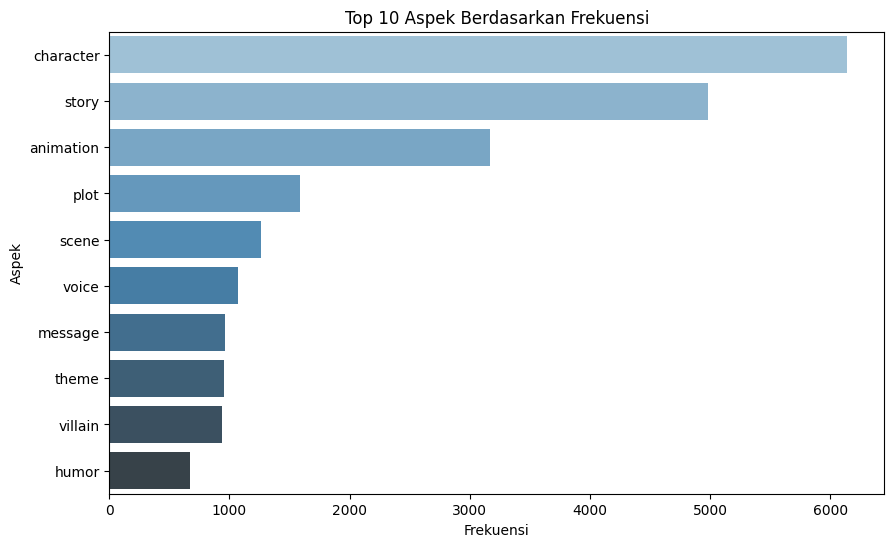

In [12]:
### 🔹 3. Bar Chart 10 Aspek Teratas

top_n = 10
top_aspects = aspect_freq_df.head(top_n)

plt.figure(figsize=(10,6))
sns.barplot(x="frequency", y="aspect", data=top_aspects, palette="Blues_d")
plt.title(f"Top {top_n} Aspek Berdasarkan Frekuensi")
plt.xlabel("Frekuensi")
plt.ylabel("Aspek")
plt.show()

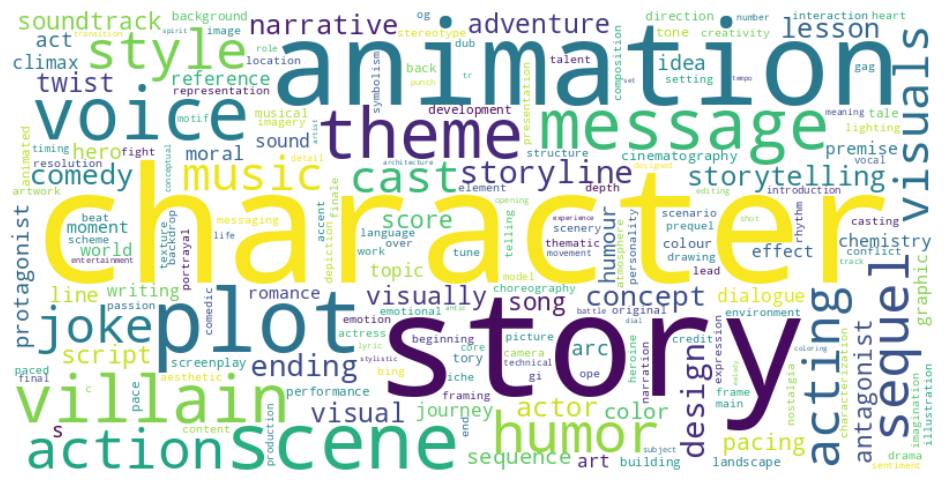

In [13]:
### 🔹 2. Wordcloud Aspek Dominan

from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(dict(aspect_counts))

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
# plt.title("WordCloud Aspek yang Paling Sering Muncul")
plt.show()

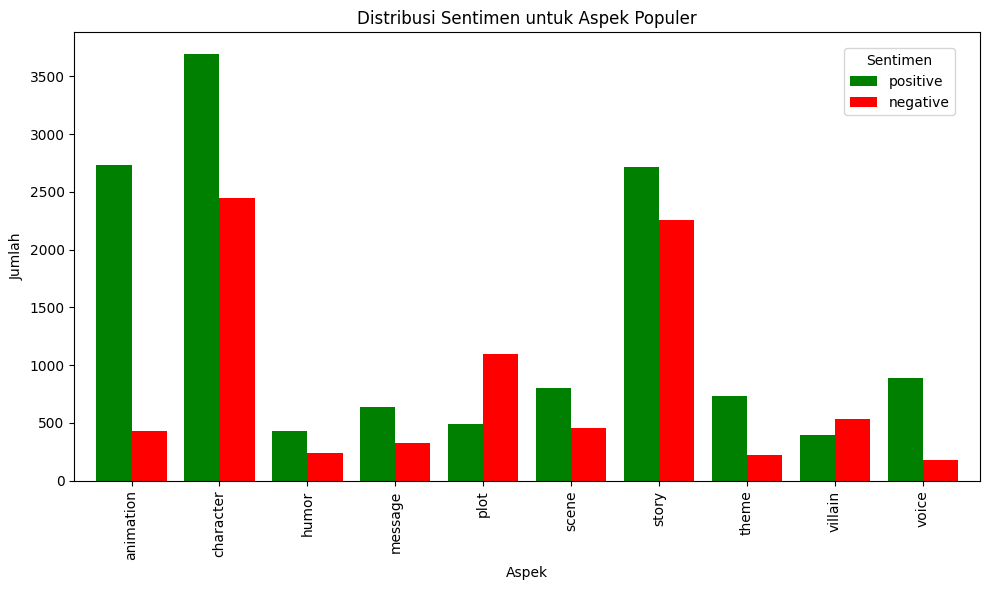

In [14]:
### 🔹 4. Distribusi Sentimen terhadap Aspek Populer

# Ambil aspek teratas saja
popular_aspects = top_aspects["aspect"].tolist()

# Filter hanya aspek populer
popular_df = pipeline_results[pipeline_results["aspect"].isin(popular_aspects)]

# Hitung distribusi sentimen untuk setiap aspek
sentiment_dist = popular_df.groupby(["aspect", "Predicted_Sentiment"]).size().reset_index(name='count')

# Pivot untuk visualisasi grouped bar
pivot_df = sentiment_dist.pivot(index="aspect", columns="Predicted_Sentiment", values="count").fillna(0)
pivot_df = pivot_df[["positive", "negative"]]  # pastikan urutan kolom

pivot_df.plot(
    kind="bar",
    stacked=False,
    figsize=(10, 6),
    color=["green", "red"],
    width=0.8
)

plt.title("Distribusi Sentimen untuk Aspek Populer")
plt.xlabel("Aspek")
plt.ylabel("Jumlah")

# Legend di pojok kanan atas di dalam plot
plt.legend(
    title="Sentimen",
    loc="upper right",
    bbox_to_anchor=(0.98, 0.98)  # sedikit geser biar rapi
)

plt.tight_layout()
plt.show()

In [15]:
import pandas as pd

# --- Filter aspek tertentu dari pipeline_results ---
pd.set_option('display.max_colwidth', None)

# 1. Aspek: plot
plot_df = pipeline_results[pipeline_results['aspect'].str.lower() == 'plot']
print("Contoh review dengan aspek 'plot':")
print(plot_df[['sentence', 'aspect', 'Predicted_Sentiment']].head(10))

# 2. Aspek: villain
villain_df = pipeline_results[pipeline_results['aspect'].str.lower() == 'villain']
print("\nContoh review dengan aspek 'villain':")
print(villain_df[['sentence', 'aspect', 'Predicted_Sentiment']].head(10))

# 3. Aspek: animation
animation_df = pipeline_results[pipeline_results['aspect'].str.lower() == 'animation']
if (animation_df['Predicted_Sentiment'] == 'positive').sum() > (animation_df['Predicted_Sentiment'] == 'negative').sum():
    print("\nContoh review dengan aspek 'animation' (positif lebih dominan):")
    print(animation_df[['sentence', 'aspect', 'Predicted_Sentiment']].head(10))

# 4. Aspek: character
character_df = pipeline_results[pipeline_results['aspect'].str.lower() == 'character']
if (character_df['Predicted_Sentiment'] == 'positive').sum() > (character_df['Predicted_Sentiment'] == 'negative').sum():
    print("\nContoh review dengan aspek 'character' (positif lebih dominan):")
    print(character_df[['sentence', 'aspect', 'Predicted_Sentiment']].head(10))

# 5. Aspek: story
story_df = pipeline_results[pipeline_results['aspect'].str.lower() == 'story']
if (story_df['Predicted_Sentiment'] == 'positive').sum() > (story_df['Predicted_Sentiment'] == 'negative').sum():
    print("\nContoh review dengan aspek 'story' (positif lebih dominan):")
    print(story_df[['sentence', 'aspect', 'Predicted_Sentiment']].head(10))

Contoh review dengan aspek 'plot':
                                                                                                                                                                                                                                                                                            sentence  \
4                                                                                                                                                                                              the plot literally involves pus running from the personification of death hoping to cling to his life   
32   finally the action and the plot itself it wa go go go from the get go i havent seen a more well paced film all year i think that is my favourite part of the dilm avatar 2 could take some notesoverall it wa truly such a blast so fun heartfelt funny genuine with a great message at it core   
79                                                                     and th

# Analysis of Dominant Aspects and Sentiment Trends

In [16]:
from collections import Counter
import pandas as pd

# Hitung frekuensi aspek dari hasil pipeline
aspect_counts = Counter(pipeline_results["aspect"])

# Ubah ke DataFrame
aspect_freq_df = pd.DataFrame(aspect_counts.items(), columns=["aspect", "frequency"])
aspect_freq_df = aspect_freq_df.sort_values(by="frequency", ascending=False)

# Tampilkan 10 teratas
print("Top 10 most frequently mentioned aspects:")
print(aspect_freq_df.head(10))

Top 10 most frequently mentioned aspects:
       aspect  frequency
7   character       6141
0       story       4980
6   animation       3164
3        plot       1588
4       scene       1264
22      voice       1067
16    message        965
14      theme        958
29    villain        938
17      humor        671


/tmp/ipython-input-4284187204.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="frequency", y="aspect", data=top_aspects, palette="Blues_d")


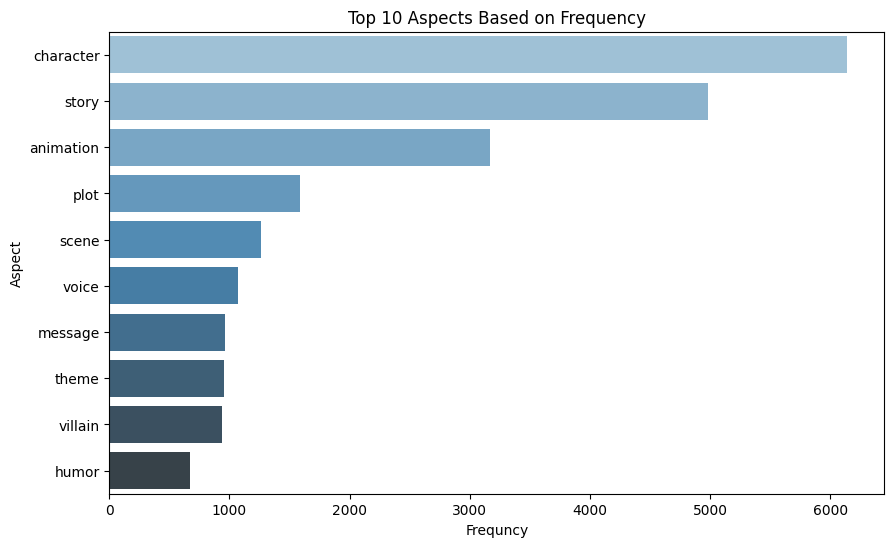

In [17]:
### 🔹 3. Bar Chart 10 Aspek Teratas

top_n = 10
top_aspects = aspect_freq_df.head(top_n)

plt.figure(figsize=(10,6))
sns.barplot(x="frequency", y="aspect", data=top_aspects, palette="Blues_d")
plt.title(f"Top {top_n} Aspects Based on Frequency")
plt.xlabel("Frequncy")
plt.ylabel("Aspect")
plt.show()

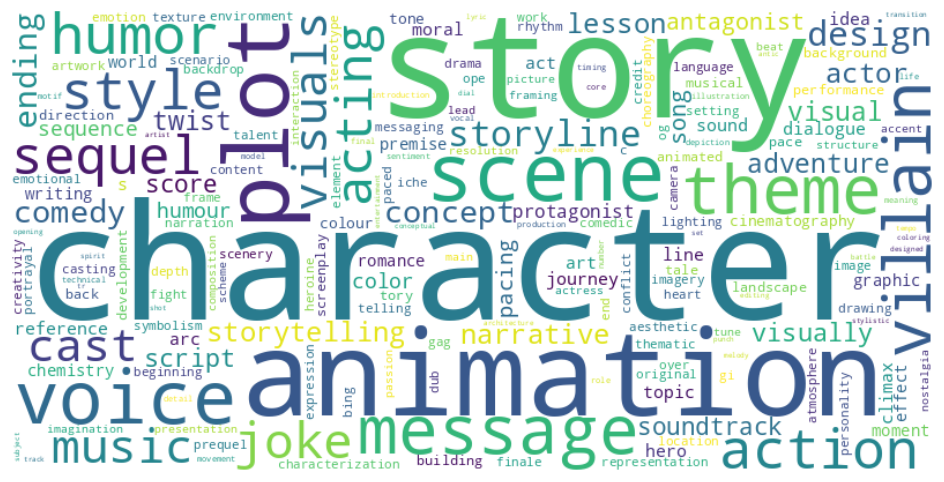

In [18]:
### 🔹 2. Wordcloud Aspek Dominan

from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(dict(aspect_counts))

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
# plt.title("WordCloud Most Frequently Occurring Aspects")
plt.show()

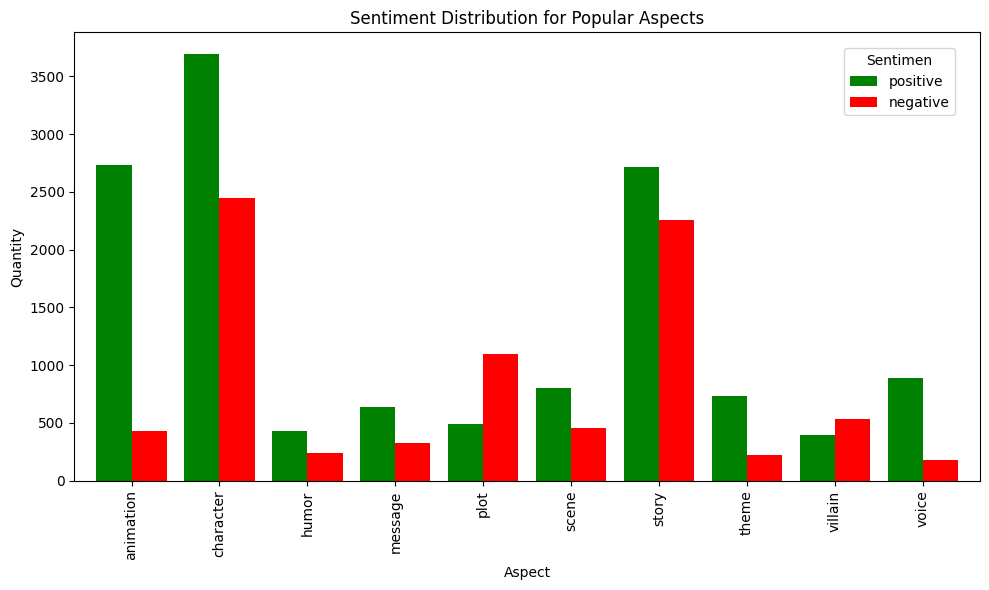

In [19]:
### 🔹 4. Distribusi Sentimen terhadap Aspek Populer

# Ambil aspek teratas saja
popular_aspects = top_aspects["aspect"].tolist()

# Filter hanya aspek populer
popular_df = pipeline_results[pipeline_results["aspect"].isin(popular_aspects)]

# Hitung distribusi sentimen untuk setiap aspek
sentiment_dist = popular_df.groupby(["aspect", "Predicted_Sentiment"]).size().reset_index(name='count')

# Pivot untuk visualisasi grouped bar
pivot_df = sentiment_dist.pivot(index="aspect", columns="Predicted_Sentiment", values="count").fillna(0)
pivot_df = pivot_df[["positive", "negative"]]  # pastikan urutan kolom

pivot_df.plot(
    kind="bar",
    stacked=False,
    figsize=(10, 6),
    color=["green", "red"],
    width=0.8
)

plt.title("Sentiment Distribution for Popular Aspects")
plt.xlabel("Aspect")
plt.ylabel("Quantity")

# Legend di pojok kanan atas di dalam plot
plt.legend(
    title="Sentimen",
    loc="upper right",
    bbox_to_anchor=(0.98, 0.98)  # sedikit geser biar rapi
)

plt.tight_layout()
plt.show()